In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from langchain_pinecone import PineconeVectorStore
from pinecone import ServerlessSpec, Pinecone
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_huggingface import HuggingFaceEndpointEmbeddings
from typing import List, TypedDict, Optional, Annotated, Literal
from operator import add
from dotenv import load_dotenv
from pydantic import BaseModel, Field
# from pinecone import ServerlessSpec, Pinecone

In [307]:
load_dotenv()

True

In [308]:
llm=ChatGoogleGenerativeAI(
    model='gemini-3.1-flash-lite-preview'
)
embeddings=HuggingFaceEndpointEmbeddings(
    model="sentence-transformers/all-MiniLM-L6-v2"
)


In [309]:
import os

PINECONE_API_KEY = os.getenv("PINECONE_API_KEY")
pc = Pinecone(api_key=PINECONE_API_KEY)

index_name="qdataset"
index = pc.Index(index_name)

In [310]:
vector_store=PineconeVectorStore(
    index=index,
    embedding=embeddings
)

In [311]:
class Question(BaseModel):
    question: str
    answer: str

In [312]:
class Query(BaseModel):
    query:str

In [313]:
class State(TypedDict):
    subject: str
    subject_description: Optional[str]
    query: Optional[str]
    difficulty: Optional[Literal['easy', 'medium', 'hard']]
    bloom_level: Optional[Literal['L1 - Remember', 'L2 - Understand', 'L3 - Apply', 'L4 - Analyze', 'L5 - Evaluate', 'L6 - Create', 'L7 - Innovate', 'Mixed']]
    n: Optional[int]
    # mode: Optional[Literal['theoretical', 'practical', 'coding', 'system_design']]
    variation_hint: Optional[str]
    variation_hints: Optional[List[str]]
    real_world_required: Optional[bool]
    enable_human_review: Optional[bool]
    human_answers: Optional[dict]
    evaluation_report: Optional[dict]
    retrieved_questions: List[dict]
    generated_questions: List[dict]

In [314]:
QUERY_SYSTEM_PROMPT = """
You are a world-class semantic query generation engine designed for a multi-domain interview question retrieval system.

========================
PRIMARY TASK
========================
Generate EXACTLY ONE high-quality, enriched semantic search query based on the given input.

========================
INPUT PARAMETERS
========================
- Subject
- Subject Description
- Difficulty
- Bloom Level
- User Query (may be empty or vague)

========================
STRICT OUTPUT RULE
========================
- Return ONLY a single query string
- Do NOT return JSON
- Do NOT include explanations, notes, or extra text
- Output must be clean and directly usable for vector search

========================
CORE OBJECTIVE
========================
Generate a query that:
- captures the intent of the user query
- uses subject description to understand domain context
- expands into related concepts and variations
- reflects complexity based on difficulty and bloom level
- maximizes semantic similarity for retrieval

========================
SUBJECT UNDERSTANDING (MANDATORY)
========================
Use the subject description to:
- identify key domain concepts
- infer relevant subtopics
- apply correct technical terminology
- stay within domain boundaries

The subject description defines:
- important concepts
- common patterns
- relevant techniques

========================
QUERY EXPANSION RULES
========================

1. Concept Expansion
- Expand the core query into:
  • related concepts
  • alternate terminology
  • domain-specific techniques

2. Problem-Solving Dimensions
- Include:
  • optimization strategies
  • constraints (latency, memory, scale, cost)
  • edge cases
  • trade-offs

3. Difficulty Mapping
- easy:
  • basic usage and direct concepts
- medium:
  • multi-step reasoning and moderate complexity
- hard:
  • complex systems, constraints, scalability, optimization

4. Bloom Level Mapping (CRITICAL)
- L1 (Recall): basic concepts, definitions
- L2 (Understand): explanations and relationships
- L3 (Apply): implementation and usage patterns
- L4 (Analyze): comparisons, debugging, trade-offs
- L5 (Evaluate): decision-making, justification, optimization
- L6 (Create): system design, architecture
- L7 (Innovate): advanced optimization, scalability, novel approaches

5. Difficulty x Bloom Calibration (EXPLICIT PER COMBINATION)
- L1-easy: define or identify one concept in direct context.
- L1-medium: classify or differentiate closely related concepts.
- L1-hard: identify precise conceptual distinctions in complex context.


- L2-easy: explain one concept or simple relationship.
- L2-medium: explain relationships across multiple components.
- L2-hard: explain behavior under constraints and edge conditions.


- L3-easy: apply a known method to a basic case.
- L3-medium: implement a multi-step approach with moderate complexity.
- L3-hard: apply approach under strict limits and corner cases.


- L4-easy: compare or analyze a straightforward case.
- L4-medium: analyze trade-offs or debug multi-factor issues.
- L4-hard: isolate root causes in complex failure scenarios.


- L5-easy: justify one practical choice with basic criteria.
- L5-medium: evaluate alternatives using measurable metrics.
- L5-hard: defend decisions under competing objectives and constraints.


- L6-easy: design a small focused solution.
- L6-medium: design an integrated subsystem with clear interfaces.
- L6-hard: architect scalable end-to-end systems with constraints.


- L7-easy: propose one concrete optimization.
- L7-medium: optimize with quantified improvements and rationale.
- L7-hard: propose novel optimizations with risk and rollback controls.

6. Variation Types (MANDATORY)
When creating the enriched query, vary across multiple axes:
- scenario domain (fintech, gaming, healthcare, e-commerce, infra)
- system shape (API, stream pipeline, batch workflow, distributed service, UI backend)
- constraints (latency, memory, cost, throughput, reliability)
- failure modes (timeouts, retries, partial outage, data skew, hotspot keys)
- optimization objective (speed, cost, resilience, consistency, developer productivity)

7. Difficulty-Specific Query Anchors (MANDATORY)
- medium: include a multi-step objective, one explicit trade-off, and at least one edge-case cue.
- hard: include scale/throughput context, at least one failure mode, and an optimization target under constraints.
- hard: prefer architecture vocabulary (distributed, partitioning, consistency, sharding, backpressure, caching).

IMPORTANT:
- DO NOT mention L1-L7 explicitly in output
- ONLY reflect their depth in the query

========================
QUERY QUALITY REQUIREMENTS
========================
The generated query MUST:
- be semantically rich and multi-dimensional
- include domain-specific terminology
- include related concepts and variations
- avoid redundancy and repetition
- avoid vague or generic phrasing
- be optimized for embedding-based retrieval

========================
FALLBACK LOGIC
========================
If the user query is:
- empty -> infer a strong domain-relevant query
- vague -> expand aggressively using subject context

========================
FINAL INSTRUCTION
========================
- Generate EXACTLY one enriched semantic query
- Ensure it is detailed, precise, and retrieval-optimized
- Do NOT output anything except the query string
"""
USER_QUERY_PROMPT = """
INPUT_PAYLOAD
- subject: {subject}
- subject_description: {subject_description}
- difficulty: {difficulty}
- bloom_level: {bloom_level}
- user_query: {query}

Use this payload with the system instructions to produce exactly one semantic query string.
"""

In [ ]:
VARIATION_HINT_SYSTEM_PROMPT = """
You generate EXACTLY {n} short variation hints for interview question generation.

Rules:
- Return exactly {n} lines of plain text.
- Each line must be 8 to 16 words.
- Each line must focus on changing scenario family, constraints, or failure mode.
- Each line must be unique.
- If difficulty is medium, hints should imply multi-step reasoning and explicit trade-offs.
- If difficulty is hard, hints should imply scale, failure modes, and optimization under constraints.
- Do not include JSON, bullets, numbering, labels, or explanations.
"""

VARIATION_HINT_USER_PROMPT = """
INPUT_PAYLOAD
- subject: {subject}
- difficulty: {difficulty}
- bloom_level: {bloom_level}
- query: {query}
- retrieved_question_count: {retrieved_question_count}
- n: {n}

Return exactly {n} concise variation hints.
"""

def generate_variation_hint(state: State):
    import random
    import re

    n = max(1, int(state.get("n", 5)))
    difficulty_key = str(state.get("difficulty", "medium")).lower()

    fallback_hints_by_difficulty = {
        "easy": [
            "Use a familiar domain with one simple operational constraint and clear objective.",
            "Keep scenario straightforward with direct requirement and one practical limitation.",
            "Choose basic workflow context and ask for a single optimization decision.",
            "Use a small-scale setting with one edge case and explicit expected behavior.",
            "Frame a direct use-case with one trade-off and clear success criterion.",
            "Anchor in common system context with minimal constraints and concrete prompt.",
        ],
        "medium": [
            "Switch industry and require multi-step reasoning with latency-cost trade-off.",
            "Reframe workflow around scaling choice plus reliability versus throughput compromise.",
            "Use distributed component context with edge case and performance trade-off.",
            "Introduce concurrent workload and force balancing consistency against response time.",
            "Add pipeline stages with failure handling and optimization under moderate constraints.",
            "Require evaluating two approaches using measurable constraints and practical trade-offs.",
        ],
        "hard": [
            "Model high-scale traffic with failure cascades and strict optimization targets.",
            "Use distributed architecture with consistency constraints, hotspots, and recovery strategy.",
            "Introduce partial outages, backpressure, and cost-latency-reliability optimization tension.",
            "Frame sharding and caching decisions under skewed load and strict SLO limits.",
            "Require resilience design for degraded mode with quantified throughput constraints.",
            "Force architecture trade-offs under memory, latency, cost, and failure-mode pressure.",
        ],
    }

    selected_fallback = fallback_hints_by_difficulty.get(
        difficulty_key,
        fallback_hints_by_difficulty["medium"]
    )

    try:
        response = llm.invoke([
            SystemMessage(content=VARIATION_HINT_SYSTEM_PROMPT.format(n=n)),
            HumanMessage(content=VARIATION_HINT_USER_PROMPT.format(
                subject=state.get("subject", ""),
                difficulty=state.get("difficulty", "medium"),
                bloom_level=state.get("bloom_level", "L3 - Apply"),
                query=state.get("query", ""),
                retrieved_question_count=len(state.get("retrieved_questions", [])),
                n=n
            ))
        ])

        content = response.content
        if isinstance(content, str):
            raw_text = content.strip()
        elif isinstance(content, list):
            parts = []
            for item in content:
                if isinstance(item, dict) and "text" in item:
                    parts.append(item["text"])
                else:
                    parts.append(str(item))
            raw_text = "".join(parts).strip()
        else:
            raw_text = str(content).strip()

        hints = []
        for line in raw_text.splitlines():
            cleaned = line.strip()
            cleaned = re.sub(r"^\s*[-*]\s*", "", cleaned)
            cleaned = re.sub(r"^\s*\d+[\).:-]\s*", "", cleaned)
            if cleaned and cleaned not in hints:
                hints.append(cleaned)
    except Exception:
        hints = []

    if len(hints) < n:
        random.shuffle(selected_fallback)
        for hint in selected_fallback:
            if hint not in hints:
                hints.append(hint)
            if len(hints) == n:
                break

    if len(hints) < n:
        all_fallback = (
            fallback_hints_by_difficulty["easy"]
            + fallback_hints_by_difficulty["medium"]
            + fallback_hints_by_difficulty["hard"]
        )
        random.shuffle(all_fallback)
        for hint in all_fallback:
            if hint not in hints:
                hints.append(hint)
            if len(hints) == n:
                break

    hints = hints[:n]
    return {
        "variation_hint": hints[0],
        "variation_hints": hints
    }



In [316]:
def generate_query(state: State):
    response = llm.invoke([
        SystemMessage(content=QUERY_SYSTEM_PROMPT),
        HumanMessage(content=USER_QUERY_PROMPT.format(
            subject=state["subject"],
            subject_description=state["subject_description"],
            difficulty=state["difficulty"],
            bloom_level=state["bloom_level"],
            query=state.get("query", "")
        ))
    ])

    # Extract string from LLM response
    query = response.content[0]['text']

    return {
        "query": query
    }

In [317]:
def retrieve_questions(state: State):
    results = vector_store.similarity_search(
        state.get("query", ""),
        # "DSA",
        k=state.get("n", 5),
        filter={
            "subject": {"$eq": state["subject"]},
            "difficulty": {"$eq": state["difficulty"]},
            "bloom_level": {"$eq": state["bloom_level"]},
        }
    )

    formatted_results = []

    for doc in results:
        formatted_results.append({
            "question": doc.metadata.get("question_text", ""),
            "answer": doc.metadata.get("answer_text", "")
        })
    print(formatted_results)

    return {
        "retrieved_questions": formatted_results
    }

In [318]:
QUESTION_GENERATION_SYSTEM_PROMPT = """
You are an expert technical interviewer and question-generation engine.

Goal: generate alternate interview questions that preserve concept and difficulty without copying wording.

OUTPUT CONTRACT (STRICT)
- Return ONLY valid JSON.
- No markdown, no code fences, no explanations.
- Output must be parseable with json.loads.
- Output type: JSON array.
- Output length: exactly {N}.
- id values: start at 1 and increment by 1.

REQUIRED FIELDS FOR EACH ITEM
- id: integer
- question_text: string
- answer_text: string
- topic_tags: array of short tags
- estimated_answer_time_sec: integer

PER-QUESTION REQUIREMENTS
1. Preserve the same core concept as the paired original question.
2. Preserve the same reasoning depth for the target bloom level.
3. Preserve the same difficulty target.
4. Change wording, scenario, constraints, numbers, and structure.
5. Include all of these parts in question_text:
   - context/scenario
   - problem/challenge
   - at least one explicit constraint
   - focused prompt/ask
6. Generate answer_text for each new question.
7. Keep answer_text technically correct, concise, and aligned with the generated question.
8. Use retrieved answers as reference context, but do not copy them verbatim.
9. Keep the wording clear, specific, and interview-grade.

WORD COUNT RULES
- easy: minimum 35 words
- medium: minimum 50 words
- hard: minimum 65 words

DIVERSITY ACROSS OUTPUTS
- No repeated scenario domain.
- No repeated constraint style.
- No repeated phrasing templates.

RUN-TO-RUN VARIATION (MANDATORY)
- Treat generation_run_id and variation_hints from the user payload as diversity signals.
- Use different variation hints across the generated set to create diverse scenarios.
- For the same input, produce a fresh set each run by changing scenario families and constraint combinations.
- Never print generation_run_id or variation_hints in the output.

MODE GUIDANCE
- theoretical: concept and reasoning focus
- practical: real-world systems and trade-offs
- coding: algorithmic/implementation focus
- system_design: architecture and scalability focus

REAL-WORLD ENFORCEMENT
If {true_or_false} is true:
- include realistic scale numbers (for example RPS, latency, data volume)
- include at least one strong operational constraint

BLOOM LEVEL INTENT
- L1 - Remember: define or identify
- L2 - Understand: explain or interpret
- L3 - Apply: implement or use
- L4 - Analyze: analyze or debug
- L5 - Evaluate: evaluate or justify
- L6 - Create: design or architect
- L7 - Innovate: propose or optimize

DIFFICULTY x BLOOM CALIBRATION (EXPLICIT PER COMBINATION)
- L1-easy: ask for one definition or identification in direct context.
- L1-medium: classify or differentiate related concepts in realistic context.
- L1-hard: identify subtle distinctions in advanced constrained scenarios.
- L2-easy: explain one concept simply and clearly.
- L2-medium: explain relationships among multiple components.
- L2-hard: explain interactions under constraints and edge conditions.
- L3-easy: apply a known method to a basic case.
- L3-medium: implement a multi-step solution with trade-offs.
- L3-hard: apply approach under strict limits and corner cases.
- L4-easy: analyze a straightforward comparison or issue.
- L4-medium: debug or analyze multi-factor trade-offs.
- L4-hard: isolate root causes in complex failures at scale.
- L5-easy: justify one option with basic criteria.
- L5-medium: evaluate alternatives using measurable metrics.
- L5-hard: defend decisions under competing objectives and constraints.
- L6-easy: design a small focused component.
- L6-medium: design an integrated subsystem with interfaces.
- L6-hard: architect scalable resilient end-to-end systems.
- L7-easy: propose one concrete improvement.
- L7-medium: optimize with quantified gains and rationale.
- L7-hard: propose novel optimization with risk and rollback plan.

MEDIUM DIFFICULTY PROFILE (MANDATORY WHEN difficulty=medium)
- Require 2-3 linked reasoning steps.
- Include at least two explicit constraints and one clear trade-off.
- Include at least one non-trivial edge case.
- answer_text should justify why the chosen approach is reasonable.

HARD DIFFICULTY PROFILE (MANDATORY WHEN difficulty=hard)
- Require system-scale conditions or high-complexity interactions.
- Include at least three strong constraints (for example latency, cost, memory, reliability).
- Include at least one failure-mode condition and mitigation expectation.
- answer_text should include strategy, trade-off analysis, and risk-aware justification.

VARIATION TYPES (MANDATORY ACROSS THE GENERATED SET)
- scenario domain variation
- constraint variation (latency, memory, cost, throughput, reliability)
- system-shape variation (API, stream, batch, distributed)
- failure-mode variation (timeouts, retries, partial outage, skew, hotspot)
- objective variation (performance, cost, resilience, maintainability)

SELF-CHECK BEFORE FINAL OUTPUT
- JSON is valid and parseable
- exactly {N} items
- id sequence is correct
- word_count matches question_text
- concept is preserved from original_question
- wording is not duplicated from original_question
- answer_text exists and is non-empty for every item
If any check fails, regenerate and output only the corrected JSON array.
"""

In [319]:
QUESTION_GENERATION_USER_PROMPT = """
INPUT_PAYLOAD
- subject: {subject}
- subject_description: {subject_description}
- difficulty: {difficulty}
- bloom_level: {bloom_level}
- real_world_required: {true_or_false}
- n: {N}
- generation_run_id: {generation_run_id}
- variation_hints:
{variation_hints}

ORIGINAL_QUESTIONS
{retrieved_questions}

Use this payload with the system instructions to generate the response.
"""

In [320]:
def human_review_answers(state: State):
    generated = state.get("generated_questions", [])
    if not generated:
        return {}

    enable_prompt = bool(state.get("enable_human_review", True))
    provided = state.get("human_answers") or {}
    collected_answers = {}

    if enable_prompt:
        print("\nHUMAN ANSWER STEP")
        print("Answer each question below. Press Enter to submit blank if you want to skip.\n")

    for idx, item in enumerate(generated, start=1):
        if not isinstance(item, dict):
            continue

        qid = str(item.get("id", idx))
        prefilled = str(provided.get(qid, "")).strip()
        if prefilled:
            collected_answers[qid] = prefilled
            continue

        if not enable_prompt:
            collected_answers[qid] = ""
            continue

        question_text = str(item.get("question_text", "")).strip()
        print(f"Question {idx} (id={qid}):")
        print(question_text)
        answer = input("Your answer: ").strip()
        collected_answers[qid] = answer
        print("")

    return {"human_answers": collected_answers}

In [321]:
def generate_questions(state: State):
    import json
    import random
    import uuid

    n = state.get("n", 5)
    difficulty = state.get("difficulty", "medium")
    bloom_level = state.get("bloom_level", "L3 - Apply")
    real_world_required = bool(state.get("real_world_required", False))

    generation_run_id = uuid.uuid4().hex[:12]
    variation_hints = state.get("variation_hints") or []

    if not variation_hints:
        variation_hints = [
            "switch to a different industry and operational bottleneck",
            "change failure mode and recovery constraints",
            "focus on throughput optimization under strict latency",
            "use memory-cost tradeoff with scale constraints",
            "introduce edge-case heavy production behavior",
            "reframe around reliability and degraded-mode handling",
        ]
        random.shuffle(variation_hints)
        variation_hints = variation_hints[:n]

    variation_hints_text = "\n".join(f"- {hint}" for hint in variation_hints)

    # Higher temperature for question generation to improve run-to-run diversity.
    question_llm = ChatGoogleGenerativeAI(
        model="gemini-3.1-flash-lite-preview",
        temperature=1.15,
        top_p=0.95,
    )

    response = question_llm.invoke([
        SystemMessage(content=QUESTION_GENERATION_SYSTEM_PROMPT.format(
            N=n,
            true_or_false=str(real_world_required).lower()
        )),
        HumanMessage(content=QUESTION_GENERATION_USER_PROMPT.format(
            subject=state["subject"],
            subject_description=state["subject_description"],
            difficulty=difficulty,
            bloom_level=bloom_level,
            true_or_false=real_world_required,
            N=n,
            generation_run_id=generation_run_id,
            variation_hints=variation_hints_text,
            retrieved_questions=state.get("retrieved_questions", [])
        ))
    ])

    raw_content = response.content
    if isinstance(raw_content, str):
        raw_text = raw_content.strip()
    elif isinstance(raw_content, list):
        parts = []
        for item in raw_content:
            if isinstance(item, dict) and "text" in item:
                parts.append(item["text"])
            else:
                parts.append(str(item))
        raw_text = "".join(parts).strip()
    else:
        raw_text = str(raw_content).strip()

    try:
        results = json.loads(raw_text)
    except json.JSONDecodeError:
        start = raw_text.find("[")
        end = raw_text.rfind("]")
        if start == -1 or end == -1 or end <= start:
            raise ValueError("Model did not return a valid JSON array for generated questions.")
        results = json.loads(raw_text[start:end + 1])

    if not isinstance(results, list):
        raise ValueError("Generated questions output must be a JSON array.")

    # Ensure answer_text is always present; fallback to matched retrieved answer when missing.
    answer_lookup = {
        item.get("question", ""): item.get("answer", "")
        for item in state.get("retrieved_questions", [])
        if isinstance(item, dict)
    }
    for item in results:
        if not isinstance(item, dict):
            continue
        answer_text = str(item.get("answer_text", "")).strip()
        if not answer_text:
            original_q = item.get("original_question", "")
            item["answer_text"] = answer_lookup.get(original_q, "")

    return {
        "generated_questions": results
    }

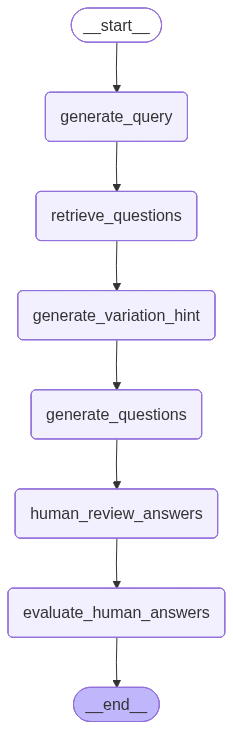

In [322]:
if "human_review_answers" not in globals():
    def human_review_answers(state: State):
        return {}

EVALUATION_SYSTEM_PROMPT = """
You are an expert technical interviewer evaluating candidate answers.

Return ONLY valid JSON with this exact schema:
{
  "overall_score": integer,
  "overall_assessment": "string",
  "strengths": ["string"],
  "improvement_areas": ["string"],
  "per_question": [
    {
      "id": "string",
      "score": integer,
      "verdict": "correct|partially_correct|incorrect",
      "correctness": "string",
      "coverage": "string",
      "feedback": "string",
      "expected_points": ["string"]
    }
  ]
}

Strict scoring rubric:
- score must be integer from 0 to 10
- incorrect/irrelevant/blank answer -> score 0
- partially correct answer -> score 1 to 6
- correct and well-supported answer -> score 7 to 10
- do NOT award non-zero score to random guesses or one-word irrelevant answers
- evaluate using question_text, reference_answer, and human_answer only
"""

EVALUATION_USER_PROMPT = """
Evaluate the following Q&A records and produce the required JSON only.

Records:
{records_json}
"""

def evaluate_human_answers(state: State):
    import json

    generated = state.get("generated_questions", [])
    human_answers = state.get("human_answers") or {}

    if not generated:
        return {
            "evaluation_report": {
                "overall_score": 0,
                "overall_assessment": "No generated questions available for evaluation.",
                "strengths": [],
                "improvement_areas": ["Generate questions before evaluation."],
                "per_question": []
            }
        }

    records = []
    for idx, item in enumerate(generated, start=1):
        if not isinstance(item, dict):
            continue
        qid = str(item.get("id", idx))
        records.append({
            "id": qid,
            "question_text": str(item.get("question_text", "")).strip(),
            "reference_answer": str(item.get("answer_text", "")).strip(),
            "human_answer": str(human_answers.get(qid, "")).strip()
        })

    response = llm.invoke([
        SystemMessage(content=EVALUATION_SYSTEM_PROMPT),
        HumanMessage(content=EVALUATION_USER_PROMPT.format(
            records_json=json.dumps(records, ensure_ascii=False)
        ))
    ])

    content = response.content
    if isinstance(content, str):
        raw_text = content.strip()
    elif isinstance(content, list):
        parts = []
        for entry in content:
            if isinstance(entry, dict) and "text" in entry:
                parts.append(entry["text"])
            else:
                parts.append(str(entry))
        raw_text = "".join(parts).strip()
    else:
        raw_text = str(content).strip()

    try:
        report = json.loads(raw_text)
    except json.JSONDecodeError:
        start = raw_text.find("{")
        end = raw_text.rfind("}")
        if start == -1 or end == -1 or end <= start:
            raise ValueError("Model did not return valid JSON for evaluation report.")
        report = json.loads(raw_text[start:end + 1])

    if not isinstance(report, dict):
        raise ValueError("Evaluation report must be a JSON object.")

    per_question_raw = report.get("per_question", [])
    by_id = {}
    if isinstance(per_question_raw, list):
        for item in per_question_raw:
            if isinstance(item, dict):
                by_id[str(item.get("id", ""))] = item

    normalized = []
    for rec in records:
        qid = rec["id"]
        model_item = by_id.get(qid, {})
        verdict = str(model_item.get("verdict", "incorrect")).strip().lower()
        human_answer = rec["human_answer"]
        token_count = len([t for t in human_answer.split() if t.strip()])

        score = model_item.get("score", 0)
        try:
            score = int(score)
        except Exception:
            score = 0
        score = max(0, min(10, score))

        # Hard guardrails to prevent inflated scores for wrong/blank answers.
        if token_count == 0:
            score = 0
            verdict = "incorrect"
        elif token_count <= 2 and verdict != "correct":
            score = 0
            verdict = "incorrect"
        elif verdict in {"incorrect", "wrong", "irrelevant"}:
            score = 0
            verdict = "incorrect"

        normalized.append({
            "id": qid,
            "score": score,
            "verdict": verdict if verdict in {"correct", "partially_correct", "incorrect"} else "incorrect",
            "correctness": str(model_item.get("correctness", "")).strip(),
            "coverage": str(model_item.get("coverage", "")).strip(),
            "feedback": str(model_item.get("feedback", "")).strip(),
            "expected_points": model_item.get("expected_points", []) if isinstance(model_item.get("expected_points", []), list) else []
        })

    total = sum(item["score"] for item in normalized)
    overall_score = int(round((total / (10 * len(normalized))) * 100)) if normalized else 0

    report["per_question"] = normalized
    report["overall_score"] = overall_score

    if overall_score == 0 and normalized:
        report["overall_assessment"] = "All submitted answers were incorrect, blank, or insufficiently supported."

    return {"evaluation_report": report}

builder = StateGraph(State)
builder.add_node('generate_query', generate_query)
builder.add_node('retrieve_questions', retrieve_questions)
builder.add_node('generate_variation_hint', generate_variation_hint)
builder.add_node('generate_questions', generate_questions)
builder.add_node('human_review_answers', human_review_answers)
builder.add_node('evaluate_human_answers', evaluate_human_answers)

builder.add_edge(START, 'generate_query')
builder.add_edge('generate_query', 'retrieve_questions')
builder.add_edge('retrieve_questions', 'generate_variation_hint')
builder.add_edge('generate_variation_hint', 'generate_questions')
builder.add_edge('generate_questions', 'human_review_answers')
builder.add_edge('human_review_answers', 'evaluate_human_answers')
builder.add_edge('evaluate_human_answers', END)
graph = builder.compile()
graph

In [323]:
initial_state=State(
    subject="Data Structures & Algorithms (DSA)",
    subject_description="Data structures and algorithms are fundamental concepts in computer science that deal with the organization and manipulation of data. Understanding these concepts is crucial for developing efficient and scalable software solutions.",
    difficulty="easy",
    bloom_level="L1 - Recall",
    n=5,
    # mode="practical",
    real_world_required=True,
    enable_human_review=True,
    human_answers={},
    evaluation_report={},
    retrieved_questions=[],
    generated_questions=[]
)
graph.invoke(initial_state)

[{'question': 'In a social media platform, your user profile lookup service handles 10,000 read requests per second, requiring sub-millisecond response times to maintain user experience. Identify the underlying data structure commonly used in memory-resident key-value stores that provides O(1) average time complexity for insertions and lookups. List the specific properties of this structure that allow for such high performance and define how it manages collisions in a constrained memory environment where latency is the highest priority.', 'answer': 'DIRECT ANSWER: The hash table (or hash map) is the standard data structure for O(1) average time complexity lookups in memory-resident stores. CORE LOGIC: - Hash functions map arbitrary keys to fixed integer indices. - Direct array indexing allows O(1) access to buckets. - Load factor management keeps the table sparse enough to minimize collision chains. REAL-WORLD HOOK: Redis utilizes an open-addressed hash table with incremental rehashing

{'subject': 'Data Structures & Algorithms (DSA)',
 'subject_description': 'Data structures and algorithms are fundamental concepts in computer science that deal with the organization and manipulation of data. Understanding these concepts is crucial for developing efficient and scalable software solutions.',
 'query': 'define the core properties, time complexity, and standard use cases for fundamental data structures including arrays, linked lists, stacks, queues, and hash maps',
 'difficulty': 'easy',
 'bloom_level': 'L1 - Recall',
 'n': 5,
 'variation_hint': 'Explain the memory allocation differences between contiguous arrays and dynamic linked list pointer nodes.',
 'variation_hints': ['Explain the memory allocation differences between contiguous arrays and dynamic linked list pointer nodes.',
  'Compare the time complexity of element insertion in stacks versus queues for data processing.',
  'Describe how hash map collision resolution techniques directly impact average case search t

In [ ]:
def retrieve_questions(state: State):
    results = vector_store.similarity_search(
        state.get("query", ""),
        # "DSA",
        k=state.get("n", 5),
        filter={
            "subject": {"$eq": state["subject"]},
            "difficulty": {"$eq": state["difficulty"]},
            "bloom_level": {"$eq": state["bloom_level"]},
        }
    )

    formatted_results = []

    for doc in results:
        formatted_results.append({
            "question": doc.metadata.get("question_text", ""),
            "answer": doc.metadata.get("answer_text", "")
        })
    print(formatted_results)

    return {
        "retrieved_questions": formatted_results
    }